# DetChar Tutorial
_Francesco Di Renzo, on behalf of the Virgo DetChar group - February 2024 Virgo Week_ 

This is a crash course on how to access Virgo data and perform basic data analysis and detector characterization tasks from the machines at the EGO Computing Center. 

In its style, this tutorial is similar to those of the [Open Data Workshops](https://gwosc.org/), which could be a useful reference and complement: [link to github repo](https://github.com/gw-odw/odw-2023).

## Preliminary notions

If you've made it this far, it means you know how to use the Linux command line, and open a Jupyter notebook.

Now we will see how to use some python packages to access Virgo data and perform simple data analysis operations.

The GW analysis specifi libraries we will use in this tutorial are the following:

- [PythonVirgoTools](https://scientists.virgo-gw.eu/PythonDoc/html/doc/PythonVirgoTools.html) - collection of Python functions for interacting with Virgo data
- [GWpy](https://gwpy.github.io/) - python package for gravitational-wave astrophysics, including data processing and plotting functionalities

Additionally, we will use the following standard Python libraries (and a few others):

- [NumPy](https://numpy.org/) - Think of it as the tool for doing linear algebra
- [SciPy](https://scipy.org/) - Think of it as the toolbox of mathematical and signal analysis algorithms
- [Matplotlib](https://matplotlib.org/) - Useful library for creating plots to include in your papers
- [pandas](https://pandas.pydata.org/) - Offers data structures and operations to manipulate numeric tables and time series

## Accessing Virgo data in Cascina
We will use the `getChannel` function of Python `virgotools`, which will return a `FrVector` object.

In [1]:
from virgotools import getChannel

# The following is a "magic function" that select the backend of iPython. It will results later:
%matplotlib inline  

ModuleNotFoundError: No module named 'virgotools'

In [2]:
gps = 1387540818
ch = "V1:Hrec_hoft_16384Hz"

FrV = getChannel(ch, gps, 10)

Main `FrVect` attributes:
- `data` - The numeric value stored in it
- `gps` - The starting GPS time of this data
- `fsample` - Sample rate in Hz
- `time` - Array of times *starting from 0!
- `unit` - Units
- `name` - Name of the channel

Let's print some of them:

In [3]:
print(f"This is the name of the channel: {FrV.name}\nand these are its units: {FrV.unit}")

This is the name of the channel: V1:Hrec_hoft_16384Hz
and these are its units: strain


Select a specific GPS time of your choice converting from UTC:

In [131]:
from gwpy.time import to_gps, from_gps

gps = to_gps("2023-12-25 12:00").gpsSeconds

### Convert FrVect to TimeSeries

In [6]:
from gwpy.timeseries import TimeSeries

def FrV_to_TS(frV):
	"""Convert FrVect objects to gwpy TimeSeries

	Parameters
	----------
	frV : `virgotools.FrVect`
		Python virgotools frame vector

	Returns
	-------
	TimeSeries
		GWpy TimeSeries corresponding to ``frV``    
	"""
	from astropy.units import Unit, dimensionless_unscaled
	try:
		unit = Unit(frV.unit)
	except:
		unit = dimensionless_unscaled
	return TimeSeries(data=frV.data, t0=frV.gps, sample_rate=frV.fsample, unit=unit, channel=FrV.name)

Let's do the convertion:

In [7]:
TS = FrV_to_TS(FrV)

For the coming examples, maybe it will be convenient to have just a single function that directly imports data into `TimeSeries` of GWpy:

In [10]:
def read2TS(*args, **kwargs):
    """
    This funtion has the same exact parameters as `virgotools` `getChannel` but it returns a `TimeSeries`.
    """
    with getChannel(*args, **kwargs) as frv:
        return FrV_to_TS(frv)

## Plot time series data

Finally, let us see how our data looks like:

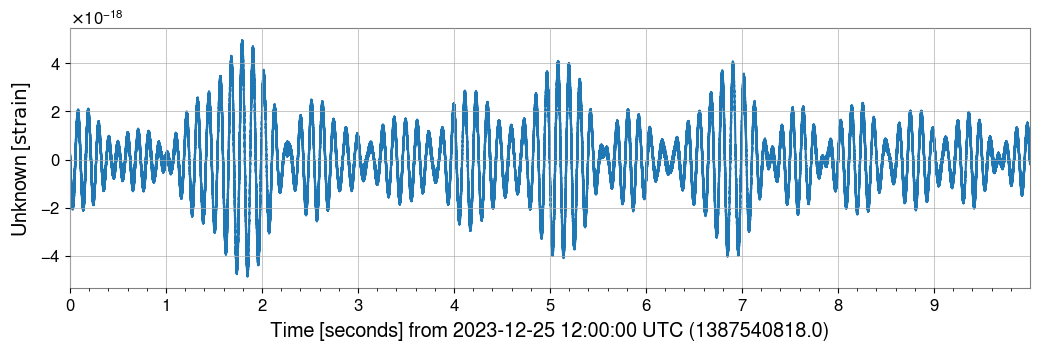

In [8]:
TS.plot();

Why don't adding a bunch of customizations? 

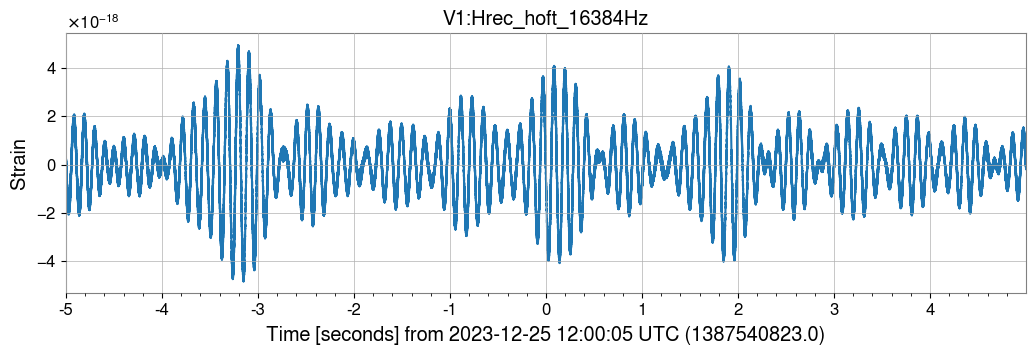

In [9]:
plot = TS.plot()
ax = plot.gca()
ax.set(ylabel="Strain", title=TS.channel.name, epoch=gps+5)
plot.show()

## Read trend data
Let's choose for example the BNS range.

In [12]:
bns_ch = "V1:Hrec_Range_BNS"
bnsTS = read2TS("trend", bns_ch, gps, 3600)

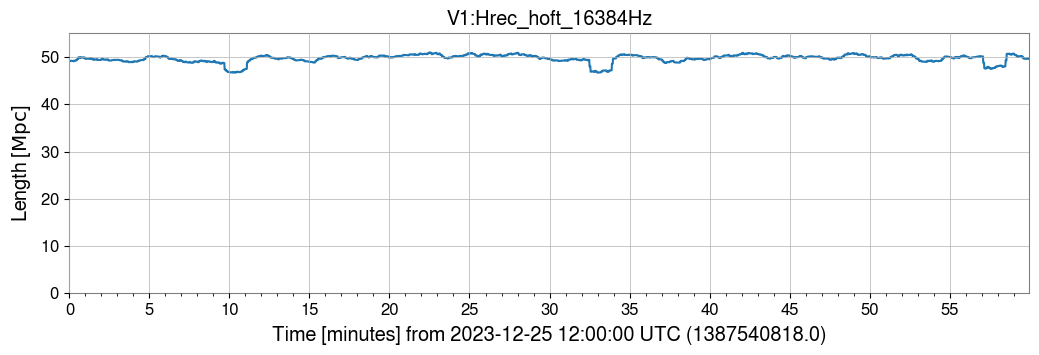

In [13]:
bnsTS.plot(title=bnsTS.channel.name, ylim=(0,55));

## Data Quality Flags

There are some channels that represent the state or the operational mode of the detector, for example:

- `V1:META_ITF_LOCK_index` representing the locking status of the detector. Refer to the [metatron nodes](https://scientists.virgo-gw.eu/PythonDoc/html/doc/Automation/userapps/doc/index.html#module-ITF_LOCK) for a description of the meaning of all of its values. E.g., the value of 135 correspnds to Low Noise 3.
- `V1:DQ_META_ITF_Mode` represent the whay the detector is operated. E.g., the value -13 corresponds to DQ Studies

Let's create the DQ segments for the entire mini-Engineering run: Dec 24, to Jan 1.

In [14]:
chDQ = "V1:META_ITF_LOCK_index"

start = to_gps("2023-12-24 16:00").gpsSeconds
end = to_gps("2024-01-01 12:00").gpsSeconds

DQTS = read2TS("trend", chDQ, start, end)

Now, let's convert it to a `StateTimeSeries` (boolean array) and then to a `DataQualityFlag` (a collection of segments of good data):

In [21]:
state_val = 125
sTS = DQTS >=state_val 

DQ = sTS.to_dqflag(label="Low Noise")

And it is immediate to plot it:

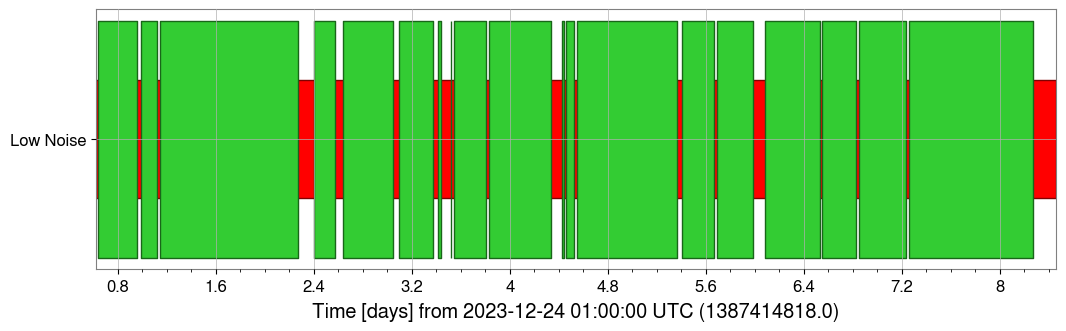

In [23]:
DQ.plot();

Make a plot with DQ bar:

In [24]:
bnsTS = read2TS("trend", bns_ch, start, end)

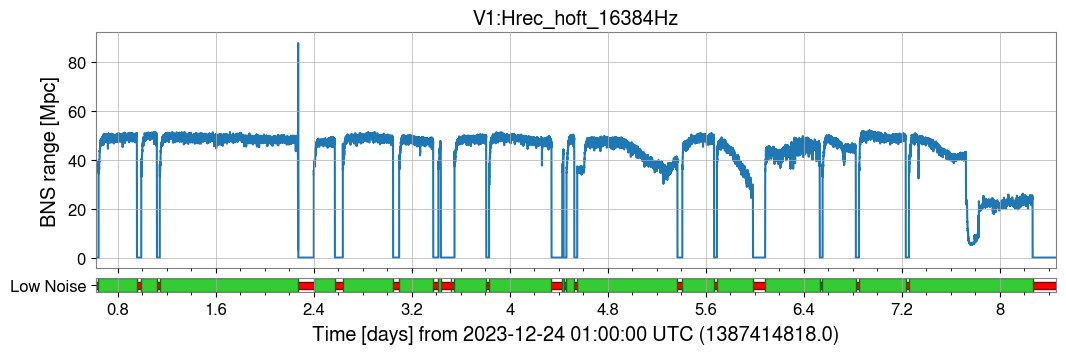

In [26]:
plot = bnsTS.plot(title=bnsTS.channel.name, ylabel="BNS range [Mpc]")
ax = plot.gca()
plot.add_segments_bar(DQ, ax=ax, pad=.1, height=.14)
plot.show()

The x-axis units are not that convenient. They can be imporved with `matplotlib.dates`, but this is [left for exercise](https://matplotlib.org/stable/api/dates_api.html). 

## Basic signal processing

Let's examine the spectral content of our strain data over one segment of low noise data:

In [37]:
start, end = DQ.active[6]

print(f"That segment lasted {(end-start)/60:.0f} minutes")

That segment lasted 31 minutes


In [40]:
ch = "V1:Hrec_hoft_20000Hz"
hTS = read2TS(ch, start, end)

We don't need to consider its frequency content up to Nyquist frequency of 20000 Hz, so we can downsample it to save memory:

In [41]:
hTS = hTS.resample(5000)

Now, a sensitivity curve:

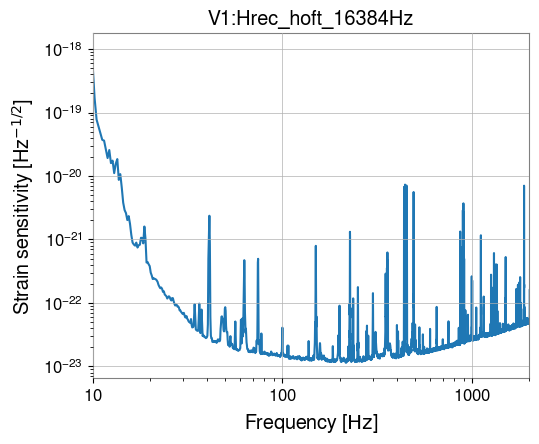

In [45]:
asdFS = hTS.asd(4,2)

asdFS.plot(xlim=(10,2000), ylabel="Strain sensitivity [Hz$^{-1/2}$]", title=hTS.channel.name);

The two numbers used as parameters for the estimating the Amplitude Spectral Density are the `fftlength` and the `overlap` between consecutive FFTs.

Now we import a second channel and examine the coherence with the former:

In [46]:
darmTS = read2TS("V1:LSC_DARM", start, end).resample(5000)

In [52]:
cohFS = hTS.coherence(darmTS, 4, 2)

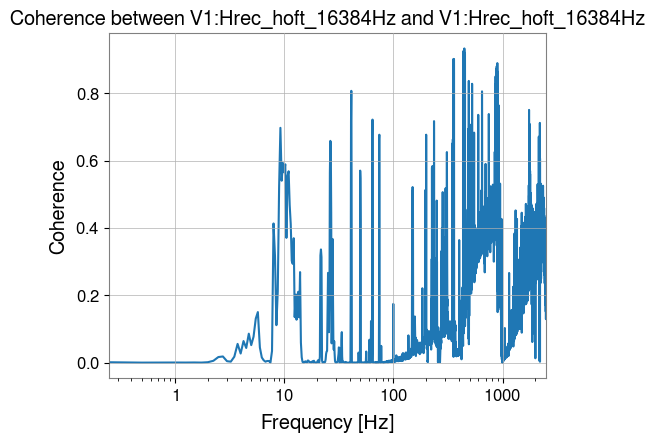

In [54]:
cohFS.plot(ylabel="Coherence", title=f"Coherence between {hTS.channel.name} and {darmTS.channel.name}");

Now, we can make a spectrogram:

In [90]:
hSpec = hTS.spectrogram(16,4,2)**.5

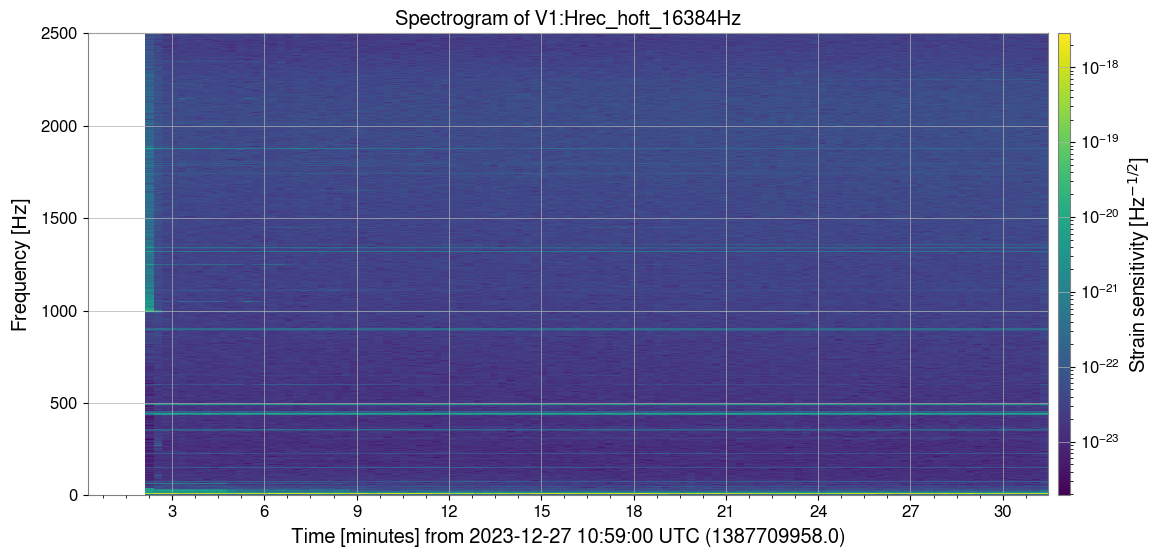

In [102]:
plot = hSpec.plot(norm="log")
ax = plot.gca()
ax.colorbar(label="Strain sensitivity [Hz$^{-1/2}$]")
ax.set(title="Spectrogram of "+hSpec.channel.name)
plot.show()

What about a median-normalized spectrogram:

In [93]:
mSpec = hSpec / hSpec.median(axis=0)[None,:]

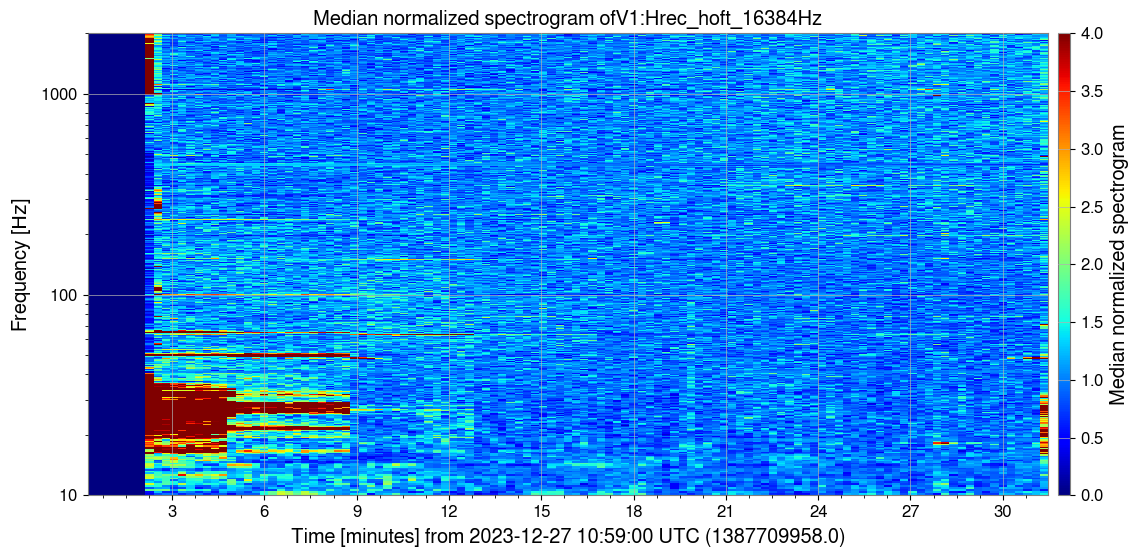

In [103]:
plot = mSpec.plot(cmap="jet", vmax=4, yscale="log", ylim=(10,2000))
ax = plot.gca()
ax.colorbar(label="Median normalized spectrogram")
ax.set(title="Median normalized spectrogram of"+mSpec.channel.name)
plot.show()

or a Rayleigh spectrogram (Ref. Virgo DetChar paper, Class.Quant.Grav. 40 (2023) 18, 185005):

In [101]:
raySpec = hTS.rayleigh_spectrogram(16, 4, 2)

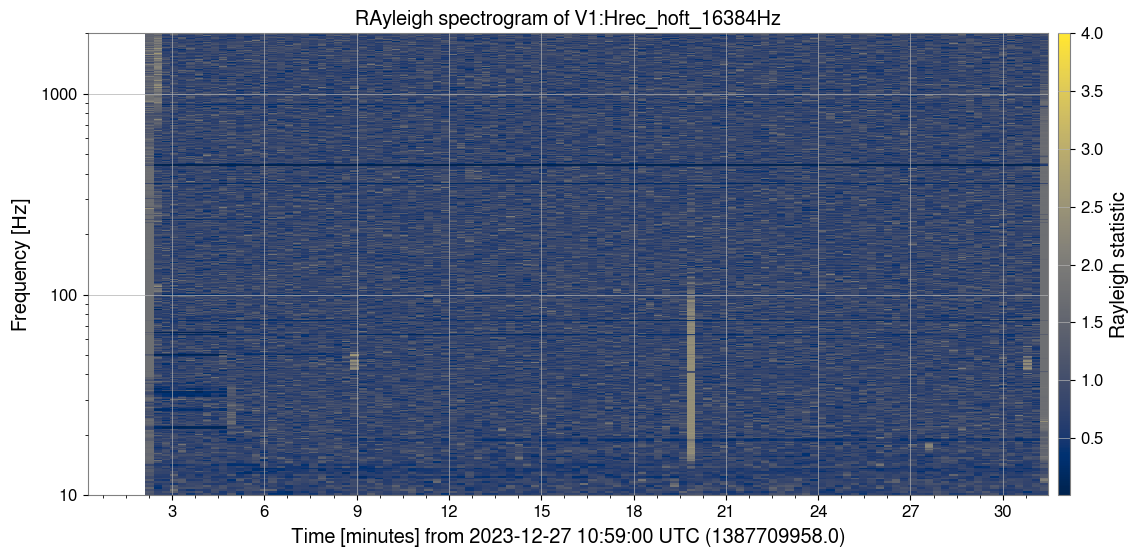

In [106]:
plot = raySpec.plot(cmap="cividis", vmax=4, yscale="log", ylim=(10,2000))
ax = plot.gca()
ax.colorbar(label="Rayleigh statistic")
ax.set(title="RAyleigh spectrogram of "+raySpec.channel.name)
plot.show()

## Reading channels

Where to start for examining other Virgo channels? You can refer to the channels shown in the VIM or to the .DetChar standard channels described [here](https://wiki.virgo-gw.eu/DataAnalysis/DetChar/DetCharChannels).

Otherwise, the following functions do the trick:

In [113]:
from typing import Literal
import numpy as np
import pandas as pd

def convert_to_list(column_name):
    """
    Remove this decorator if you want to take the result as a pandas dataframe
    """
    def decorator(func):
        def wrapper(*args, **kwargs):
            # Call the original function to get the DataFrame
            result_df = func(*args, **kwargs)
            
            # Check if the result is a Pandas DataFrame
            if not isinstance(result_df, pd.DataFrame):
                raise ValueError("The decorated function should return a Pandas DataFrame.")

            # Check if the specified column exists in the DataFrame
            if column_name not in result_df.columns:
                raise ValueError(f"Column '{column_name}' not found in the DataFrame.")

            # Convert the specified column to a list
            result_list = result_df[column_name].tolist()

            return result_list

        return wrapper
    return decorator

# Remove this ->
@convert_to_list("name")
def find_channels(gps=None, specs=None, rmlist=None, chtype: Literal["adc","proc","sim"]="adc",
                  frame: Literal["raw","trend","trend100"]="raw", fsample=None, units=None):    
    """This function finds all the channels matching the patterns specifed with `specs` in all the provided GWF files.

    Parameters
    ----------
    gps : int, float, optional
        GPS time at which to read the name of the channels. If no value is provided, the latest frame is read.    
    specs : str, list, optional
        Single string, possibly including wildcards `*`, or list of strings specifying which channels to import. If `None`, all the channels in the GWF(s) will be returned. By default None
    rmlist : str, list, optional
        Single string or list of strings specifying the patterns to exclude. By default None
    chtype : str, optional
        The frame format supports three different types of channels: ADC (also referred to as raw), processed, and simulated. Possible options: adc, proc, sim. Default: adc
    frame : str, optional
        Type of frame: 'raw', 'trend', or 'trend100' (not always available)
    units : str, list, optional
        Desired unit of the channel. Notice that channel units are a mess in Virgo. 
    fsample : int, float, list, optional
        If a single value is passed, all the channels whose frequency matches the specified value are returned. If a list of two values (possibly one of which is None) all the channels with frequencies within the two values are returned.
        
    Returns
    -------
    list
        List of strings with the names of the channels matching the above parameters

    """
    from virgotools import FrameFile

    chdict = {}

    with FrameFile(frame) as ffl:
        if gps is not None:
            use_method = f"get_frame({gps})"
        else:
            use_method = "last_frame()"

        with eval(f"ffl.{use_method}") as frame:
            chdict["name"] = [str(adc.contents.name) for adc in eval(f"frame.iter_{chtype}()")]
            chdict["units"] = [str(adc.contents.units) for adc in eval(f"frame.iter_{chtype}()")]
            chdict["sampleRate"] = [adc.contents.sampleRate for adc in eval(f"frame.iter_{chtype}()")]
    chdf = pd.DataFrame(chdict)        

    #return chdf
    from fnmatch import fnmatchcase
    
    # Specified channels
    if isinstance(specs, (str,(list,tuple))):
        cspecfilt = np.any(np.array([chdf.name.apply(lambda x: fnmatchcase(x, chsp)).values for chsp in np.atleast_1d(specs)]),
                            axis=0)
        chdf = chdf[cspecfilt]

    # Remove some channels
    if isinstance(rmlist, (str, (list,tuple))):
        rmspecfilt = np.any(np.array([chdf.name.apply(lambda x: fnmatchcase(x, chsp)).values for chsp in np.atleast_1d(rmlist)]),
                            axis=0)
        chdf = chdf[~rmspecfilt]

    # Select units
    if isinstance(units, (str, (list,tuple))):
        uspecfilt = np.any(np.array([chdf.units.apply(lambda x: fnmatchcase(x, chsp)).values for chsp in np.atleast_1d(units)]),
                            axis=0)
        chdf = chdf[uspecfilt]

    # Select frequency
    if isinstance(fsample, (int, float)):
        fspecfilt = chdf.sampleRate.values==fsample
        chdf = chdf[fspecfilt]
    elif isinstance(fsample, (list,tuple)):
        fspecfilt = (chdf.sampleRate.values>=(fsample[0] or -1)) & (chdf.sampleRate.values<=(fsample[-1] or np.inf)) 
        chdf = chdf[fspecfilt]

    return chdf

In [114]:
ENVch = find_channels(gps=start, chtype="adc", frame="trend", specs=["V1:ENV*","V1:*_rms","V1:*_TE*"])

print(f"Found {len(ENVch)} matching the provided specs.")

Found 11973 matching the provided specs.


In [116]:
ENVch

['V1:WEB_TIMING_moni_elapsed_time_rms',
 'V1:WEB_TIMING_moni_Time_FS_rms',
 'V1:WEB_TIMING_moni_CfgChange_rms',
 'V1:WEB_PCal_fast_elapsed_time_rms',
 'V1:WEB_PCal_fast_Time_FS_rms',
 'V1:WEB_PCal_fast_CfgChange_rms',
 'V1:WEB_NCal_elapsed_time_rms',
 'V1:WEB_NCal_Time_FS_rms',
 'V1:WEB_NCal_CfgChange_rms',
 'V1:WEB_ALS_readout_elapsed_time_rms',
 'V1:WEB_ALS_readout_Time_FS_rms',
 'V1:WEB_ALS_readout_CfgChange_rms',
 'V1:WEB_ALS_fast_elapsed_time_rms',
 'V1:WEB_ALS_fast_Time_FS_rms',
 'V1:WEB_ALS_fast_CfgChange_rms',
 'V1:WEB_ALS_Tpro_processed_packets_rms',
 'V1:WEB_ALS_Tpro_elapsed_time_rms',
 'V1:WEB_ALS_BPC_elapsed_time_rms',
 'V1:WEB_ALS_BPC_Time_FS_rms',
 'V1:WEB_ALS_BPC_CfgChange_rms',
 'V1:VAC_WE_HLS_TEMP_MEAN',
 'V1:VAC_WE_HLS_H7D4_183_TEMP',
 'V1:VAC_WE_HLS_H7D4_123_TEMP',
 'V1:VAC_WE_HLS_H7D2_001_TEMP',
 'V1:VAC_VALVEBIGWI_CRYO_TEMP',
 'V1:VAC_VALVEBIGWE_CRYO_TEMP',
 'V1:VAC_VALVEBIGNI_CRYO_TEMP',
 'V1:VAC_VALVEBIGNE_CRYO_TEMP',
 'V1:VAC_TUBEMC_RACK_TEMP',
 'V1:VAC_TUBE1500

## Glitches

In [119]:
from glob import glob
import os

def find_trigger_files(ch, start, end, trigpath="/data/*/omicron/", ext="root"):
    """Functions that searches for omicron trigger files and returns the list of those referred to the specified time interval.

    Parameters
    ----------
    ch : str
        Name of the channel we want to look for omicron trigger files
    start : float, int
        Start GPS time of the triggers
    end : float, int
        End GPS time of the triggers
    trigpath : str, optional
        Path where to look for omicron triggers. It can include wildcards. By default "/data/*/omicron/"
    ext : str, optional
        Extension of the files used to store glitch triggers, by default "root"

    Returns
    -------
    list of str
        List of paths to the files
    """    

    allfiles = glob(os.path.join(trigpath,"{}/{}_OMICRON".format(*ch.split(":")),"**",f"*.{ext}"))
    allstart,alldur = np.array([glf.rstrip(".root").split("-")[-2:] for glf in allfiles]).astype(int).T
    
    try:
        rightfiles = np.asarray(allfiles)[(allstart+alldur>start) & (end>allstart)]
    except TypeError:
        print(f"No glitch tirgger files found in the selected interval: {start}-{end}")
        return []
    return rightfiles

Find trigger files specific for the selected time interval

In [122]:
trigfiles = find_trigger_files("V1:Hrec_hoft_16384Hz", start, end)

Import the glitch triggers into an `EventTable`:

In [124]:
from gwpy.table import EventTable
gltab = EventTable.read(trigfiles.tolist(), treename='triggers;1', nproc=3)
gltab.sort("time")

print(f"{len(gltab)} glitch triggers have been found")

665901 glitch triggers have been found


In [125]:
gltab

time,frequency,q,snr,tstart,tend,fstart,fend,amplitude,phase,tstart_us
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32
1387700037.746093,718.5041813754985,72.47796636776955,5.033920381656635,1387700037.742187,1387700037.75,713.4127574485557,723.6319413468044,7.897605992707286e-23,-0.6667226725604817,742188
1387700039.423339,258.0391581837544,5.518918645844859,5.170539425074096,1387700039.422851,1387700039.423828,237.18800290788482,280.7233348224594,5.2910444173579323e-23,0.7850502122560686,422852
1387700039.424316,258.0391581837544,5.518918645844859,5.009389974205423,1387700039.423828,1387700039.424805,237.18800290788482,280.7233348224594,5.1261392049067633e-23,0.8251529206191665,423828
1387700039.600586,1342.6788124709608,38.073078774317565,5.145910335758647,1387700039.599609,1387700039.601563,1324.6123378027457,1360.9916969736778,1.6422967912748204e-22,2.393096698640226,599609
1387700039.87854,1175.8658572474303,5.518918645844859,5.161994541832614,1387700039.878418,1387700039.878662,1080.8486445668657,1279.2360162456557,1.3222222141544324e-22,0.9582019465584369,878418
1387700039.878662,1226.4031224588955,10.506111217615068,5.6195142510118705,1387700039.878418,1387700039.878907,1169.2955869170519,1286.2997479897485,1.5218140060148915e-22,2.9590790557813142,878418
1387700039.878662,1349.1216806111363,10.506111217615068,5.072479958791457,1387700039.878418,1387700039.878907,1286.2997479897485,1415.0117901675303,1.5023467911740638e-22,-0.5611840675539828,878418
1387700039.878784,1175.8658572474303,5.518918645844859,5.349447624857427,1387700039.878662,1387700039.878907,1080.8486445668657,1279.2360162456557,1.370237497486977e-22,1.016127052716509,878662
1387700039.879028,1175.8658572474303,5.518918645844859,5.184066331012454,1387700039.878906,1387700039.879151,1080.8486445668657,1279.2360162456557,1.3278758059440426e-22,1.0770447430620214,878906


### Time Clustering

In [126]:
window = .1 # sec (0.1 default)
gltabc = gltab.cluster("time", rank="snr", window=window)
print(f"{len(gltabc)} glitches after clustering ({len(gltabc)*100/len(gltab):.1f})%")

19533 glitches after clustering (2.9)%


For convenience, we convert the table to a Pandas DataFrame:

In [127]:
gldf = gltabc.to_pandas()

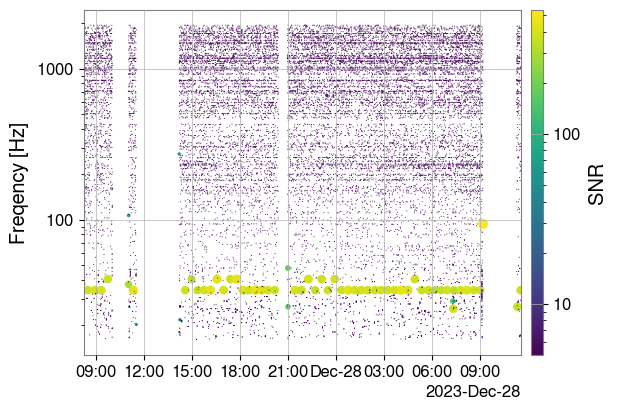

In [136]:
from gwpy.plot import Plot
import matplotlib.dates as mdates

plot = Plot()
ax = plot.gca()
ax.scatter(gldf.time/86400+mdates.date2num(from_gps(0)),
           gldf.frequency, s=gldf.snr/10,c=gldf.snr ,edgecolor="none")
ax.set(yscale="log", ylabel="Freqency [Hz]")
ax.colorbar(label="SNR", norm="log")

locator = mdates.AutoDateLocator(minticks=5,maxticks=10)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
from matplotlib.ticker import AutoMinorLocator

ax.margins(x=0)
plot.show()

Select one specific glitch:

In [139]:
gl = gldf.iloc[555]

In [141]:
hTS = read2TS(ch, gl.time-32, gl.time+32)

In [142]:
Qtr = hTS.q_transform(outseg=(gl.time-10,gl.time+10))

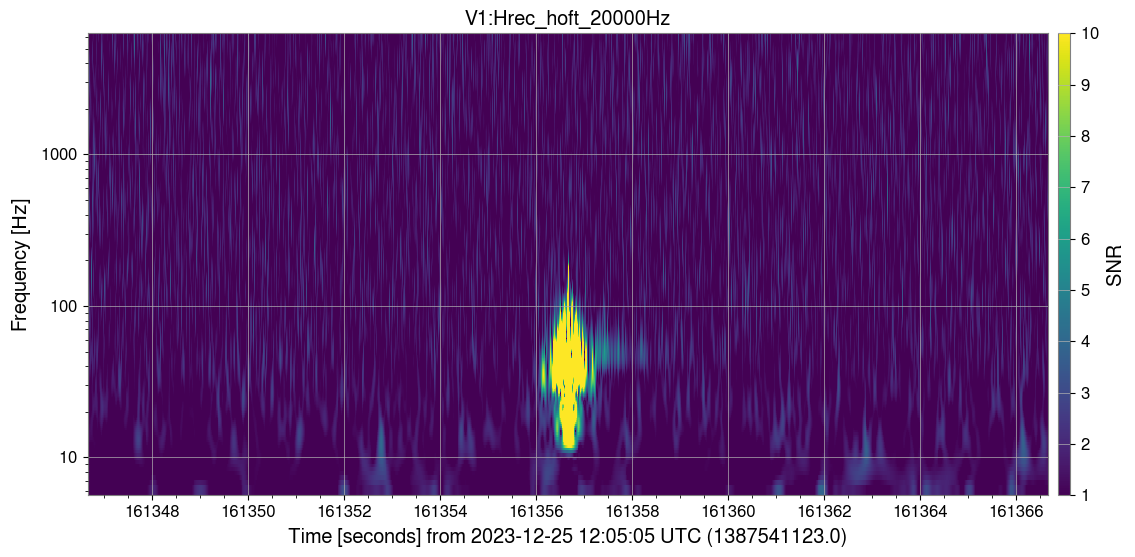

In [145]:
plot = (Qtr.abs()**.5).plot(vmin=1, vmax=10, #norm='log'
                )
ax = plot.gca()
ax.set_xscale('seconds', epoch=gps+305)
ax.set(yscale='log',
      title=ch)
ax.colorbar(label="SNR")
plot.show()

Plot omicron triggers:

In [148]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize,LogNorm

def plot_omicron_triggers(gps, trigfile, window=[-1,1], norm="linear", cmap="Blues", clim=None, ax=None, ylim=None):
    """
    Function to plot glitch triggers
    """
    # Create axis if not present
    if ax is None:
        new_ax = True
        plot = Plot()
        ax = plot.gca()
    else:
        new_ax = False

    # Select triggers
    subgltab = trigfile[(trigfile["time"]>gps+window[0]) & (trigfile["time"]<gps+window[1])]
    if clim is None:
        clim = [6.5, subgltab["snr"].max()]
    subgltab.sort("snr")

    def cscale(x, xmin, xmax, norm="linear", palette="Blues"):
        colors_ = eval(f"plt.cm.{palette}")
        if norm=="linear":
            return colors_((x-xmin)/(xmax-xmin))
        elif norm=="log":
            return colors_(np.log((x-xmin)/(xmax-xmin) +1)/np.log(2))
        else:
            raise ValueError

    for row in subgltab:
        x1 = row["tstart"]
        dx = row["tend"]-x1
        y1 = row["fstart"]
        dy = row["fend"]-y1
        p = Rectangle((x1,y1), dx, dy, alpha=.8, edgecolor="none",
                      facecolor=cscale(row["snr"],clim[0], clim[1], norm=norm, palette=cmap))
        ax.add_patch(p)

    if norm=="linear":
        NormFunc = Normalize
    elif norm=="log":
        NormFunc = LogNorm

    cbr = plot.colorbar(plt.cm.ScalarMappable(norm=NormFunc(clim[0],clim[1]), cmap=cmap),
                 ax=ax, orientation='vertical', label='SNR')
    cbr.ax.set_ylabel("SNR", rotation=270, labelpad=10)
    ax.set_xscale("auto-gps", epoch=gps)
    ax.set(ylim=(ylim or (10,1000)), ylabel="Frequency [Hz]", yscale="log", xlim=(gps+window[0],gps+window[1]))


    if new_ax:
        return plot

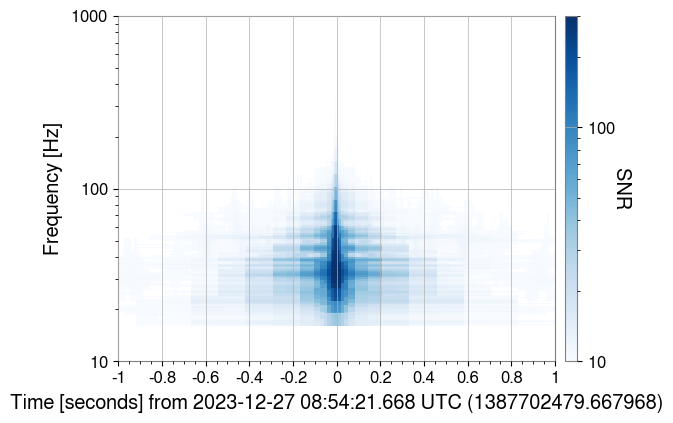

In [149]:
plot = plot_omicron_triggers(gl.time, gltab, window=(-1,1), norm="log", cmap="Blues", clim=(10,300), ax=None)